# Sentiment Analysis with a Bidirectional LSTM

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
**Bidirectional LSTM** that operates directly on word sequences.

Unlike the feedforward ANN which uses a TF-IDF bag-of-words representation, the
BiLSTM reads each review token-by-token in both directions, allowing it to capture
word order and local context (e.g. *"not good"* vs *"good"*).

**Pipeline overview**
```
Raw text  →  Lightweight cleaning  →  Vocabulary (train only)
          →  Integer-encoded + padded sequences
          →  Embedding layer  →  BiLSTM  →  [h_fwd ; h_bwd]  →  Linear classifier
```

## Setup & Imports

Standard scientific Python stack plus PyTorch for the neural network and a small set
of project-local helpers.

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils import (
    device_check,
    fit, evaluate, plot_confusion_matrix,
    Vocabulary, SentimentBiLSTM,
    save_bilstm_run,
)

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB = True  # Set False to disable wandb logging
SEED      = 1

# Assumes the notebook is launched from Lab1/src.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent
WANDB_DIR    = PROJECT_DIR
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR   = PROJECT_DIR / 'models'

# Make results reproducible
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1 K Amazon Reviews

### Load Pre-split Data

In [3]:
train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

def preprocess_seq(df: pd.DataFrame) -> pd.DataFrame:
    """Lightweight cleaning for sequence models.

    Unlike the TF-IDF pipeline we keep stopwords here — they carry positional
    context that the BiLSTM can exploit (e.g. 'not good' vs 'good').
    Steps: lowercase → strip email/IP addresses → remove punctuation & digits.
    """
    df = df.copy()
    s = df['Sentence'].str.lower()
    s = s.str.replace(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', '', regex=True)
    s = s.str.replace(r'(?:\d{1,3}\.){3}\d{1,3}', '', regex=True)
    s = s.str.replace(r'[^\w\s]', ' ', regex=True)
    s = s.str.replace(r'\d+', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    df['Sentence'] = s
    return df

train_df = preprocess_seq(train_df)
val_df   = preprocess_seq(val_df)
test_df  = preprocess_seq(test_df)

X_train = train_df['Sentence'].tolist()
X_val   = val_df['Sentence'].tolist()
X_test  = test_df['Sentence'].tolist()
y_train = train_df['Class'].values.astype('int64')
y_val   = val_df['Class'].values.astype('int64')
y_test  = test_df['Class'].values.astype('int64')

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### Vocabulary

A `Vocabulary` maps each unique token to an integer ID.
It is built **only from the training set** to avoid data leakage.

Two special tokens are always reserved:
- **Index 0 — `<PAD>`**: used to right-pad short sequences to a fixed length; the
  embedding layer ignores this index.
- **Index 1 — `<UNK>`**: assigned to any token not seen during training (out-of-vocabulary).

`min_freq=1` keeps every token from the (small) 1 K training set.

In [4]:
vocab = Vocabulary().build(X_train, min_freq=1)
print(f'Vocab size: {len(vocab):,}')

Vocabulary built — 1,582 tokens  (min_freq=1)
Vocab size: 1,582


### Tokenization & Padding

Each review is encoded to a fixed-length integer sequence:

1. **Tokenize**: split on whitespace.
2. **Truncate**: keep at most `MAX_SEQ_LEN` tokens.
3. **Pad**: right-pad shorter sequences with `<PAD>` (index 0).
4. **Map to `LongTensor`**: the embedding layer expects integer (not float) inputs.

We choose `MAX_SEQ_LEN = 128`, which covers the vast majority of reviews without
excessive padding overhead.

In [5]:
MAX_SEQ_LEN = 128

def encode_corpus(texts, vocab, max_len):
    return torch.tensor(
        [vocab.encode(t, max_len) for t in texts],
        dtype=torch.long,
    )

X_train_t = encode_corpus(X_train, vocab, MAX_SEQ_LEN)
X_val_t   = encode_corpus(X_val,   vocab, MAX_SEQ_LEN)
X_test_t  = encode_corpus(X_test,  vocab, MAX_SEQ_LEN)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

# Sanity check: show sequence lengths before padding
lengths = [len(t.split()) for t in X_train]
print(f'Sequence lengths — min: {min(lengths)}  median: {int(np.median(lengths))}  '
      f'max: {max(lengths)}  (cap: {MAX_SEQ_LEN})')

Sequence lengths — min: 1  median: 9  max: 31  (cap: 128)


### DataLoaders

The encoded tensors are wrapped in `TensorDataset` objects and handed off to
PyTorch `DataLoader`s for batching and (training) shuffling.

In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A bidirectional LSTM with a linear classification head.

```
Input (seq_len)  →  Embedding(vocab_size, 64)  →  Dropout(0.3)
                 →  BiLSTM(64→128, 1 layer)
                 →  concat [h_fwd ; h_bwd]  →  (256,)
                 →  Dropout(0.3)  →  Linear(256, 2)
```

**Why bidirectional?**  
A standard LSTM only sees left context at each time step. The backward pass gives
right context too, so the final representation captures the full sentence from
both ends — useful for sentiment where the end of a review often contradicts the
beginning (*"... but overall terrible"*).

In [7]:
EMBED_DIM  = 64
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT    = 0.3

model = SentimentBiLSTM(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = 2,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')


Trainable parameters: 300,418


### Training

The model is trained with **Adam** and **cross-entropy loss** for up to 100 epochs.
Early stopping with `patience=10` halts training if validation loss does not improve
for 10 consecutive epochs. The best-validation-loss checkpoint is restored at the end.

In [8]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
OUT_DIR       = MODELS_DIR / 'bilstm_1k'

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="BiLSTM 1K",
    tags=["Task 1.1", "BiLSTM", "1K"],
    dir=WANDB_DIR,
    config={
        "dataset":     "Amazon 1K",
        "optimizer":   type(optimizer).__name__,
        "embed_dim":   EMBED_DIM,
        "hidden_dim":  HIDDEN_DIM,
        "num_layers":  NUM_LAYERS,
        "dropout":     DROPOUT,
        "lr":          LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "epochs":      NUM_EPOCHS,
        "batch_size":  BATCH_SIZE,
        "max_seq_len": MAX_SEQ_LEN,
        "vocab_size":  len(vocab),
    },
    mode='online' if LOG_WANDB else 'disabled',
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    patience=10,
)

_ = save_bilstm_run(
    out_dir     = OUT_DIR,
    model       = model,
    vocab       = vocab,
    max_seq_len = MAX_SEQ_LEN,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = 2,
    dropout     = DROPOUT,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch   | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/100 | 0.6856     | 55.31    % | 0.6854     | 55.56    %
  2/100 | 0.6519     | 66.67    % | 0.6676     | 57.78    %
  3/100 | 0.6103     | 69.01    % | 0.6415     | 58.89    %
  4/100 | 0.5569     | 72.10    % | 0.6181     | 68.89    %
  5/100 | 0.5198     | 73.58    % | 0.5939     | 65.56    %
 10/100 | 0.3448     | 84.57    % | 0.5278     | 68.89    %
 15/100 | 0.2234     | 90.12    % | 0.5048     | 71.11    %
 20/100 | 0.1273     | 96.17    % | 0.6477     | 75.56    %
 21/100 | 0.1391     | 94.57    % | 0.8194     | 68.89    %

Early stopping triggered at epoch 21 (no improvement for 10 epochs)

Restored best weights (val loss 0.4994)


Training Accuracy,▁▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇█████
Training Loss,██▇▆▆▆▅▄▄▄▃▃▃▃▂▂▁▁▁▁▁
Validation Accuracy,▁▂▂▆▅▅▅▆▆▆███▆▆▅▅▆▆█▆
Validation Loss,▅▅▄▄▃▃▁▂▂▂▁▁▁▃▁▄▄▅▅▄█
Training Accuracy,94.5679
Training Loss,0.13915
Validation Accuracy,68.88889
Validation Loss,0.81938
test_accuracy,72
test_loss,0.4678
test_macro_f1,0.71899



BiLSTM run saved to: /root/D7047E/Lab1/models/bilstm_1k


### Evaluation on the Test Set

The saved best checkpoint is run on the held-out test set.
`evaluate` reports overall accuracy and a per-class precision/recall/F1 breakdown.

In [9]:
_ = evaluate(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    label='BiLSTM — 1K Samples',
    class_names=['Negative', 'Positive'],
)

Classification Report: BiLSTM — 1K Samples

              precision    recall  f1-score   support

    Negative      0.696     0.780     0.736        50
    Positive      0.750     0.660     0.702        50

    accuracy                          0.720       100
   macro avg      0.723     0.720     0.719       100
weighted avg      0.723     0.720     0.719       100



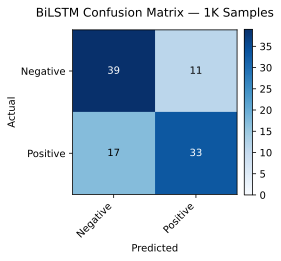

In [10]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='BiLSTM Confusion Matrix — 1K Samples',
)

---
## Scaling Up — 25 K Amazon Reviews

We now repeat the **exact same pipeline** on the larger
`amazon_cells_labelled_LARGE_25K.txt` dataset (same binary labels).
The vocabulary and model are retrained **from scratch** so they properly
reflect the larger training distribution.

Compared with the 1 K run, the main changes are:
- `min_freq=2` to prune hapax legomena from the vocabulary.
- Wider embedding and hidden dimensions to exploit the extra data.
- Larger batch size and a `ReduceLROnPlateau` scheduler.
- `pin_memory` / `num_workers` for faster GPU data loading.

### Load Pre-split Data

In [11]:
train_df = pd.read_csv(SPLITS_DIR / '25k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '25k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '25k_test.csv')

train_df = preprocess_seq(train_df)
val_df   = preprocess_seq(val_df)
test_df  = preprocess_seq(test_df)

X_train = train_df['Sentence'].tolist()
X_val   = val_df['Sentence'].tolist()
X_test  = test_df['Sentence'].tolist()
y_train = train_df['Class'].values.astype('int64')
y_val   = val_df['Class'].values.astype('int64')
y_test  = test_df['Class'].values.astype('int64')

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 20,250  |  Val: 2,250  |  Test: 2,500


### Vocabulary

With 25 K reviews the corpus is large enough to apply `min_freq=2`,
which discards tokens that appear only once. This removes typos and
very rare words that would otherwise waste embedding capacity.

In [12]:
vocab = Vocabulary().build(X_train, min_freq=2)
print(f'Vocab size: {len(vocab):,}')

Vocabulary built — 9,004 tokens  (min_freq=2)
Vocab size: 9,004


### Tokenization & Padding

Same encoding as the 1 K run: truncate to `MAX_SEQ_LEN`, right-pad with
`<PAD>` (index 0), and cast to `LongTensor`.

In [13]:
MAX_SEQ_LEN = 128

X_train_t = encode_corpus(X_train, vocab, MAX_SEQ_LEN)
X_val_t   = encode_corpus(X_val,   vocab, MAX_SEQ_LEN)
X_test_t  = encode_corpus(X_test,  vocab, MAX_SEQ_LEN)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

lengths = [len(t.split()) for t in X_train]
print(f'Sequence lengths — min: {min(lengths)}  median: {int(np.median(lengths))}  '
      f'max: {max(lengths)}  (cap: {MAX_SEQ_LEN})')

Sequence lengths — min: 2  median: 21  max: 33  (cap: 128)


### DataLoaders

In [14]:
import os

BATCH_SIZE  = 512
PIN_MEMORY  = torch.cuda.is_available()
NUM_WORKERS = min(4, os.cpu_count() or 0)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

A wider model than the 1 K run (`embed_dim=128`, `hidden_dim=256`) is used
here. A `ReduceLROnPlateau` scheduler halves the learning rate after 5
epochs of no validation-loss improvement, helping the optimizer escape
shallow plateaus on the larger dataset.

In [15]:
EMBED_DIM     = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 1
DROPOUT       = 0.3
POOL          = 'mean'
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
OUT_DIR       = MODELS_DIR / 'bilstm_25k'

model = SentimentBiLSTM(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = 2,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pool        = POOL,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='BiLSTM 25K',
    tags=['Task 1.1', 'BiLSTM', '25K'],
    dir=WANDB_DIR,
    config={
        'dataset':      'Amazon 25K',
        'optimizer':    type(optimizer).__name__,
        'embed_dim':    EMBED_DIM,
        'hidden_dim':   HIDDEN_DIM,
        'num_layers':   NUM_LAYERS,
        'dropout':      DROPOUT,
        'pool':         POOL,
        'lr':           LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'epochs':       NUM_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'max_seq_len':  MAX_SEQ_LEN,
        'vocab_size':   len(vocab),
    },
    mode='online' if LOG_WANDB else 'disabled',
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    patience=10,
    scheduler=scheduler,
)

_ = save_bilstm_run(
    out_dir     = OUT_DIR,
    model       = model,
    vocab       = vocab,
    max_seq_len = MAX_SEQ_LEN,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = 2,
    dropout     = DROPOUT,
)

Epoch   | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/100 | 0.5652     | 69.29    % | 0.4679     | 76.53    %
  2/100 | 0.4580     | 77.84    % | 0.4509     | 79.42    %
  3/100 | 0.4006     | 81.57    % | 0.3691     | 83.29    %
  4/100 | 0.3539     | 84.27    % | 0.3506     | 85.02    %
  5/100 | 0.3222     | 86.23    % | 0.3429     | 84.76    %
 10/100 | 0.3480     | 84.86    % | 0.3456     | 84.44    %
 15/100 | 0.2210     | 91.10    % | 0.3416     | 87.47    %
 20/100 | 0.1800     | 92.85    % | 0.3322     | 87.33    %
 23/100 | 0.1681     | 93.52    % | 0.3621     | 87.02    %

Early stopping triggered at epoch 23 (no improvement for 10 epochs)

Restored best weights (val loss 0.3100)


Training Accuracy,▁▃▅▅▆▆▇▇▅▅▆▇▇▇▇▇▇██████
Training Loss,█▆▅▄▄▃▃▃▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁
Validation Accuracy,▁▃▅▆▆▇▆▇▄▆▆▇███▇█▇█████
Validation Loss,█▇▄▃▂▁▅▂▅▃▂▂▁▁▂▃▁▂▃▂▂▂▃
Training Accuracy,93.52099
Training Loss,0.1681
Validation Accuracy,87.02222
Validation Loss,0.36214
test_accuracy,87.4
test_loss,0.30438
test_macro_f1,0.86781



BiLSTM run saved to: /root/D7047E/Lab1/models/bilstm_25k


### Test-Set Evaluation & Confusion Matrix

Test metrics and the confusion matrix summarize how well the model
trained on 25 K samples generalizes.

In [16]:
_ = evaluate(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    label='BiLSTM — 25K Samples',
    class_names=['Negative', 'Positive'],
)

Classification Report: BiLSTM — 25K Samples

              precision    recall  f1-score   support

    Negative      0.847     0.832     0.839       988
    Positive      0.891     0.901     0.896      1512

    accuracy                          0.874      2500
   macro avg      0.869     0.867     0.868      2500
weighted avg      0.874     0.874     0.874      2500



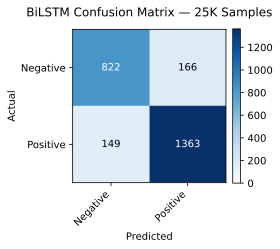

In [17]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='BiLSTM Confusion Matrix — 25K Samples',
)

---
## Video Games Reviews — 5-Class Rating

Same pipeline applied to the Video Games dataset. Key differences from
the binary sentiment tasks:
- **5 output classes** (star ratings 1–5), remapped to 0–4 for `CrossEntropyLoss`.
- **Larger corpus** (~2.56 M reviews), so we use `min_freq=5` to keep the
  vocabulary tractable.
- **Class imbalance** — 5-star reviews are ~58 % of the data; inverse-frequency
  weights are passed to `CrossEntropyLoss` to penalize minority-class errors more.

### Load Pre-split Data

Labels are raw star ratings (1–5), remapped to 0–4 before being
converted to tensors. On ~2.56 M reviews the preprocessing cell
may take a few minutes.

In [18]:
train_df = pd.read_csv(SPLITS_DIR / 'vg_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / 'vg_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')

# Note: on ~2.56 M reviews this takes a few minutes
train_df = preprocess_seq(train_df)
val_df   = preprocess_seq(val_df)
test_df  = preprocess_seq(test_df)

X_train = train_df['Sentence'].tolist()
X_val   = val_df['Sentence'].tolist()
X_test  = test_df['Sentence'].tolist()

# Remap star ratings 1-5 -> 0-4 (CrossEntropyLoss requires 0-indexed targets)
y_train = (np.asarray(train_df['Class'], dtype='int64') - 1)
y_val   = (np.asarray(val_df['Class'],   dtype='int64') - 1)
y_test  = (np.asarray(test_df['Class'],  dtype='int64') - 1)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 2,076,462  |  Val: 230,719  |  Test: 256,354


### Vocabulary

With ~2 M training reviews we apply `min_freq=5` to discard tokens that
appear fewer than five times. This keeps the vocabulary to a manageable
size while still covering the overwhelming majority of token occurrences.

In [19]:
vocab = Vocabulary().build(X_train, min_freq=5)
print(f'Vocab size: {len(vocab):,}')

Vocabulary built — 81,590 tokens  (min_freq=5)
Vocab size: 81,590


### Tokenization & Padding

Same `MAX_SEQ_LEN = 128` as before. The distribution of review lengths
in this dataset tends to be shorter than the Amazon phone reviews,
so truncation is rare in practice.

In [20]:
MAX_SEQ_LEN = 128

X_train_t = encode_corpus(X_train, vocab, MAX_SEQ_LEN)
X_val_t   = encode_corpus(X_val,   vocab, MAX_SEQ_LEN)
X_test_t  = encode_corpus(X_test,  vocab, MAX_SEQ_LEN)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

lengths = [len(t.split()) for t in X_train]
print(f'Sequence lengths — min: {min(lengths)}  median: {int(np.median(lengths))}  '
      f'max: {max(lengths)}  (cap: {MAX_SEQ_LEN})')

Sequence lengths — min: 0  median: 29  max: 6428  (cap: 128)


### DataLoaders

In [21]:
BATCH_SIZE  = 1024
PIN_MEMORY  = torch.cuda.is_available()
NUM_WORKERS = 16

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

The same architecture as the 25 K run (`embed_dim=128`, `hidden_dim=256`)
is reused with `num_classes=5`. **Inverse-frequency class weights** are
passed to `CrossEntropyLoss` to counteract the ~58 % 5-star imbalance,
so the model is penalized more heavily for errors on minority classes.

In [22]:
EMBED_DIM     = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 1
DROPOUT       = 0.3
POOL          = 'mean'
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
OUT_DIR       = MODELS_DIR / 'bilstm_vg'

model = SentimentBiLSTM(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = 5,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    pool        = POOL,
).to(device)

# Inverse-frequency class weights to counter the ~58 % 5-star imbalance
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float, device=device,
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='BiLSTM VG',
    tags=['Task 1.1', 'BiLSTM', 'VG'],
    dir=WANDB_DIR,
    config={
        'dataset':       'Video Games',
        'optimizer':     type(optimizer).__name__,
        'embed_dim':     EMBED_DIM,
        'hidden_dim':    HIDDEN_DIM,
        'num_layers':    NUM_LAYERS,
        'dropout':       DROPOUT,
        'pool':          POOL,
        'num_classes':   5,
        'lr':            LEARNING_RATE,
        'weight_decay':  WEIGHT_DECAY,
        'epochs':        NUM_EPOCHS,
        'batch_size':    BATCH_SIZE,
        'max_seq_len':   MAX_SEQ_LEN,
        'vocab_size':    len(vocab),
        'class_weights': class_weights.tolist(),
    },
    mode='online' if LOG_WANDB else 'disabled',
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    patience=10,
    scheduler=scheduler,
)

_ = save_bilstm_run(
    out_dir     = OUT_DIR,
    model       = model,
    vocab       = vocab,
    max_seq_len = MAX_SEQ_LEN,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = 5,
    dropout     = DROPOUT,
)

Epoch   | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/100 | 1.1813     | 57.28    % | 1.0959     | 64.63    %
  2/100 | 1.0744     | 62.36    % | 1.0392     | 63.24    %
  3/100 | 1.0411     | 63.79    % | 1.0243     | 65.69    %
  4/100 | 1.0278     | 64.39    % | 1.0237     | 68.98    %
  5/100 | 1.0209     | 64.68    % | 1.0132     | 67.05    %
 10/100 | 1.0076     | 65.26    % | 0.9998     | 65.30    %
 15/100 | 1.0021     | 65.49    % | 1.0011     | 65.57    %
 20/100 | 0.9990     | 65.54    % | 0.9943     | 66.35    %
 25/100 | 0.9968     | 65.65    % | 0.9974     | 68.50    %
 30/100 | 0.9949     | 65.75    % | 0.9878     | 65.95    %
 35/100 | 0.9941     | 65.77    % | 0.9904     | 62.52    %
 40/100 | 0.9735     | 66.48    % | 0.9771     | 66.75    %
 45/100 | 0.9702     | 66.56    % | 0.9871     | 69.13    %
 50/100 | 0.9685     | 66.58    % | 0.9765     | 66.92    %
 55/100 | 0.9456     | 67.31    % | 0.9752     | 67.01    %
 60/100 | 0.9379     | 67.45    % | 0.97

Training Accuracy,▁▄▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████
Training Loss,█▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁
Validation Accuracy,▂▄█▆▅▄▄▆▅▅▅▅▆▅▇▅▄▆▃▂▅▁█▆█▆▆▆▄▇▆▇▆▆▇▆▇▆▆▆
Validation Loss,█▆▆▅▅▄▄▄▄▄▄▃▃▃▄▃▃▃▃▃▃▂▃▃▃▂▁▁▁▁▂▁▁▁▁▁▂▁▁▂
Training Accuracy,68.20149
Training Loss,0.91035
Validation Accuracy,67.41144
Validation Loss,0.98756
test_accuracy,67.493
test_loss,0.97367
test_macro_f1,0.55545



BiLSTM run saved to: /root/D7047E/Lab1/models/bilstm_vg


### Test-Set Evaluation & Confusion Matrix

With 5 classes the confusion matrix is 5×5. It is row-normalized (each row
sums to 1) so that recall per class is directly readable as a proportion,
which is important given the class imbalance. Off-diagonal entries reveal
which rating buckets the model conflates.

In [23]:
_ = evaluate(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    label='BiLSTM — Video Game Reviews',
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
)

Classification Report: BiLSTM — Video Game Reviews

              precision    recall  f1-score   support

      1-star      0.723     0.733     0.728     31181
      2-star      0.339     0.434     0.381     14131
      3-star      0.362     0.488     0.416     21230
      4-star      0.390     0.472     0.427     41225
      5-star      0.891     0.769     0.825    148587

    accuracy                          0.675    256354
   macro avg      0.541     0.579     0.555    256354
weighted avg      0.716     0.675     0.691    256354



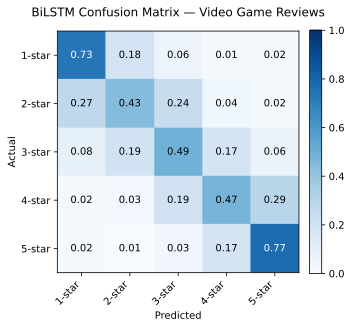

In [24]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=5,
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
    title='BiLSTM Confusion Matrix — Video Game Reviews',
    normalize=True,
)